In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load processed data
btc_df = pd.read_csv('../data/processed/BTC_USDT_processed.csv')
eth_df = pd.read_csv('../data/processed/ETH_USDT_processed.csv')

btc_df['timestamp'] = pd.to_datetime(btc_df['timestamp'])
eth_df['timestamp'] = pd.to_datetime(eth_df['timestamp'])

# Load best models (XGBoost)
xgb_btc = joblib.load('../data/models/xgb_btc.joblib')
xgb_eth = joblib.load('../data/models/xgb_eth.joblib')

# Features (same as training)
DROP_COLS = ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'future_return']
FEATURE_COLS = [c for c in btc_df.columns if c not in DROP_COLS + ['label']]

# Take test set only (last 20%)
def get_test_set(df):
    split_idx = int(len(df) * 0.8)
    return df.iloc[split_idx:].reset_index(drop=True)

btc_test = get_test_set(btc_df)
eth_test = get_test_set(eth_df)

print(f"BTC test set: {btc_test.shape}")
print(f"  Date range: {btc_test['timestamp'].iloc[0]} → {btc_test['timestamp'].iloc[-1]}")
print(f"\nETH test set: {eth_test.shape}")
print(f"  Date range: {eth_test['timestamp'].iloc[0]} → {eth_test['timestamp'].iloc[-1]}")

BTC test set: (780, 36)
  Date range: 2025-05-27 13:00:00 → 2025-04-09 18:00:00

ETH test set: (1438, 36)
  Date range: 2026-02-17 10:00:00 → 2025-08-25 12:00:00


In [3]:
# Sort by timestamp properly
btc_test = btc_test.sort_values('timestamp').reset_index(drop=True)
eth_test = eth_test.sort_values('timestamp').reset_index(drop=True)

print(f"BTC test set: {btc_test.shape}")
print(f"  Date range: {btc_test['timestamp'].iloc[0]} → {btc_test['timestamp'].iloc[-1]}")
print(f"\nETH test set: {eth_test.shape}")
print(f"  Date range: {eth_test['timestamp'].iloc[0]} → {eth_test['timestamp'].iloc[-1]}")

BTC test set: (780, 36)
  Date range: 2025-02-04 18:00:00 → 2026-03-24 12:00:00

ETH test set: (1438, 36)
  Date range: 2025-02-04 19:00:00 → 2026-03-24 07:00:00


In [4]:
def backtest(df, model, symbol, initial_capital=10000):
    capital = initial_capital
    position = 0        # how many coins we hold
    portfolio_values = []
    trades = []
    
    X = df[FEATURE_COLS]
    predictions = model.predict(X)
    
    for i in range(len(df)):
        price = df['close'].iloc[i]
        signal = predictions[i]
        timestamp = df['timestamp'].iloc[i]
        
        # BUY signal (2) — buy with all available capital
        if signal == 2 and capital > 0:
            position = capital / price
            capital = 0
            trades.append({
                'timestamp': timestamp,
                'type': 'BUY',
                'price': price,
                'position': position
            })
        
        # SELL signal (0) — sell all position
        elif signal == 0 and position > 0:
            capital = position * price
            trades.append({
                'timestamp': timestamp,
                'type': 'SELL',
                'price': price,
                'capital': capital
            })
            position = 0
        
        # Portfolio value at this moment
        portfolio_value = capital + (position * price)
        portfolio_values.append({
            'timestamp': timestamp,
            'portfolio_value': portfolio_value,
            'price': price,
            'signal': signal
        })
    
    # Final value
    final_price = df['close'].iloc[-1]
    final_value = capital + (position * final_price)
    
    # Metrics
    roi = (final_value - initial_capital) / initial_capital * 100
    
    portfolio_df = pd.DataFrame(portfolio_values)
    portfolio_df['peak'] = portfolio_df['portfolio_value'].cummax()
    portfolio_df['drawdown'] = (portfolio_df['portfolio_value'] - portfolio_df['peak']) / portfolio_df['peak'] * 100
    max_drawdown = portfolio_df['drawdown'].min()
    
    trades_df = pd.DataFrame(trades)
    buy_trades  = trades_df[trades_df['type'] == 'BUY']  if len(trades_df) > 0 else pd.DataFrame()
    sell_trades = trades_df[trades_df['type'] == 'SELL'] if len(trades_df) > 0 else pd.DataFrame()
    total_trades = len(sell_trades)
    
    # Buy and Hold comparison
    first_price = df['close'].iloc[0]
    bah_value = initial_capital / first_price * final_price
    bah_roi = (bah_value - initial_capital) / initial_capital * 100
    
    print(f"\n{'='*50}")
    print(f"{symbol} Backtesting Results")
    print(f"{'='*50}")
    print(f"Initial capital:   ${initial_capital:,.2f}")
    print(f"Final value:       ${final_value:,.2f}")
    print(f"ROI:               {roi:.2f}%")
    print(f"Max Drawdown:      {max_drawdown:.2f}%")
    print(f"Total trades:      {total_trades}")
    print(f"Buy & Hold ROI:    {bah_roi:.2f}%")
    print(f"vs Buy & Hold:     {roi - bah_roi:+.2f}%")
    print(f"{'='*50}")
    
    return portfolio_df, trades_df, {
        'symbol': symbol,
        'final_value': final_value,
        'roi': roi,
        'max_drawdown': max_drawdown,
        'total_trades': total_trades,
        'bah_roi': bah_roi
    }

btc_portfolio, btc_trades, btc_metrics = backtest(btc_test, xgb_btc, 'BTC')
eth_portfolio, eth_trades, eth_metrics = backtest(eth_test, xgb_eth, 'ETH')


BTC Backtesting Results
Initial capital:   $10,000.00
Final value:       $21,926.65
ROI:               119.27%
Max Drawdown:      -13.70%
Total trades:      49
Buy & Hold ROI:    -28.63%
vs Buy & Hold:     +147.89%

ETH Backtesting Results
Initial capital:   $10,000.00
Final value:       $62,903.36
ROI:               529.03%
Max Drawdown:      -17.37%
Total trades:      74
Buy & Hold ROI:    -21.84%
vs Buy & Hold:     +550.87%


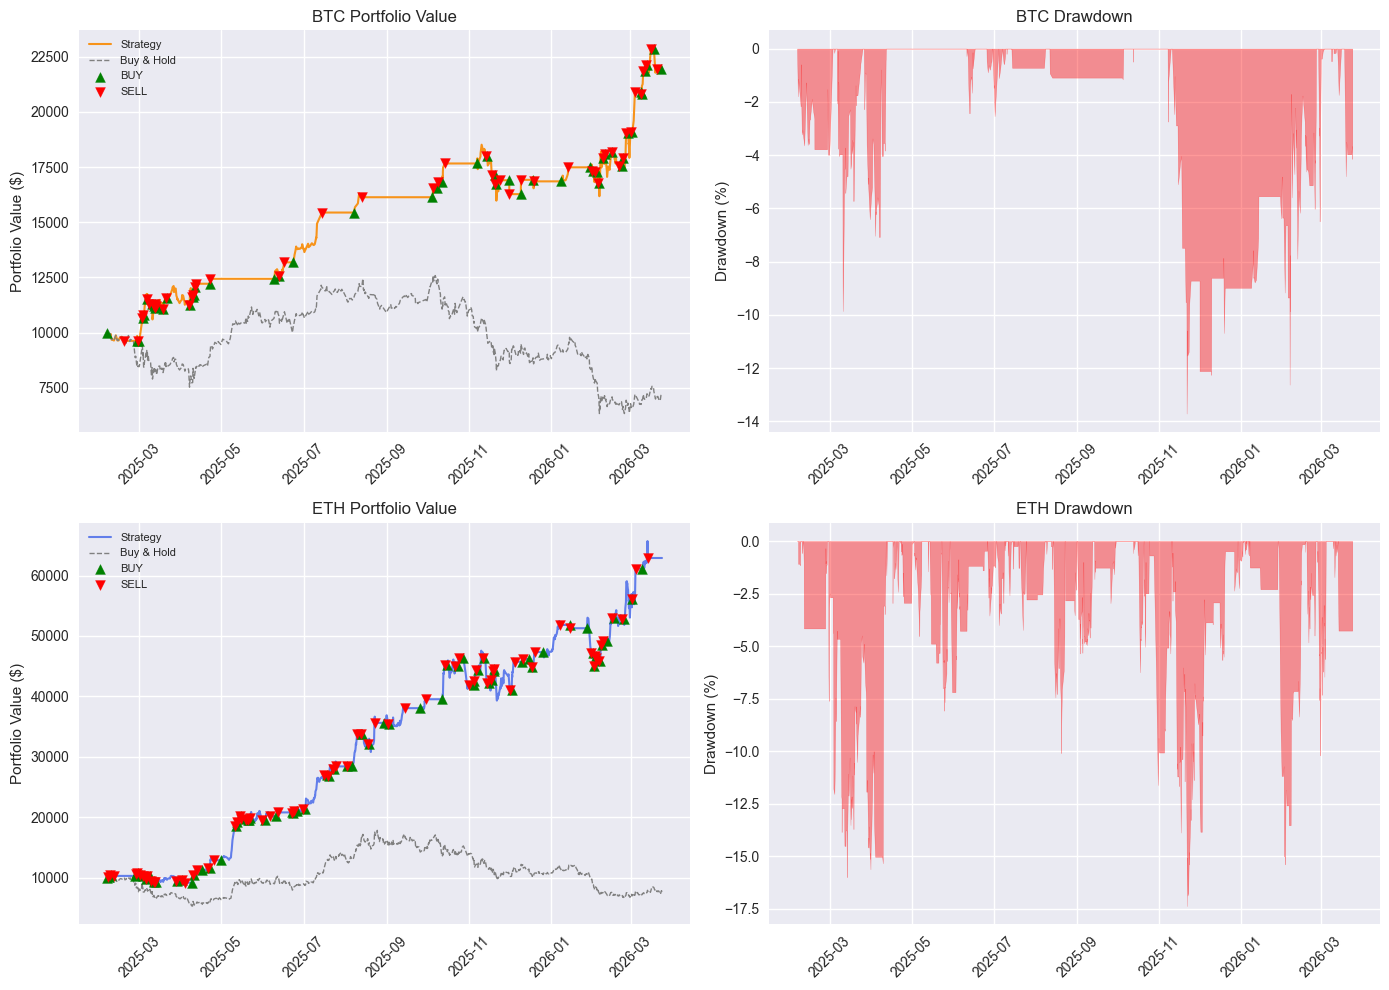

Backtest chart saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (portfolio_df, trades_df, metrics, symbol, color) in enumerate([
    (btc_portfolio, btc_trades, btc_metrics, 'BTC', '#F7931A'),
    (eth_portfolio, eth_trades, eth_metrics, 'ETH', '#627EEA')
]):
    ax1 = axes[idx][0]
    ax2 = axes[idx][1]

    # Portfolio value over time
    ax1.plot(portfolio_df['timestamp'], portfolio_df['portfolio_value'],
             color=color, linewidth=1.5, label='Strategy')

    # Buy and Hold line
    first_price = portfolio_df['price'].iloc[0]
    bah_values = 10000 / first_price * portfolio_df['price']
    ax1.plot(portfolio_df['timestamp'], bah_values,
             color='gray', linewidth=1, linestyle='--', label='Buy & Hold')

    # Mark buy and sell points
    if len(trades_df) > 0:
        buys  = trades_df[trades_df['type'] == 'BUY']
        sells = trades_df[trades_df['type'] == 'SELL']

        buy_values = []
        for _, trade in buys.iterrows():
            match = portfolio_df[portfolio_df['timestamp'] == trade['timestamp']]
            if len(match) > 0:
                buy_values.append(match['portfolio_value'].iloc[0])

        sell_values = []
        for _, trade in sells.iterrows():
            match = portfolio_df[portfolio_df['timestamp'] == trade['timestamp']]
            if len(match) > 0:
                sell_values.append(match['portfolio_value'].iloc[0])

        if buy_values:
            ax1.scatter(buys['timestamp'].iloc[:len(buy_values)],
                       buy_values, color='green', marker='^', s=50, zorder=5, label='BUY')
        if sell_values:
            ax1.scatter(sells['timestamp'].iloc[:len(sell_values)],
                       sell_values, color='red', marker='v', s=50, zorder=5, label='SELL')

    ax1.set_title(f'{symbol} Portfolio Value')
    ax1.set_ylabel('Portfolio Value ($)')
    ax1.legend(fontsize=8)
    ax1.tick_params(axis='x', rotation=45)

    # Drawdown chart
    ax2.fill_between(portfolio_df['timestamp'],
                     portfolio_df['drawdown'], 0,
                     color='red', alpha=0.4)
    ax2.set_title(f'{symbol} Drawdown')
    ax2.set_ylabel('Drawdown (%)')
    ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../docs/diagrams/backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Backtest chart saved!")